In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split

Matplotlib is building the font cache; this may take a moment.


In [9]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [10]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Missing Values:
customerID      

In [11]:
df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,20.2,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [12]:
print(df["Churn"].value_counts())

print("\nPercentage:")
print(df["Churn"].value_counts(normalize=True) * 100)

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


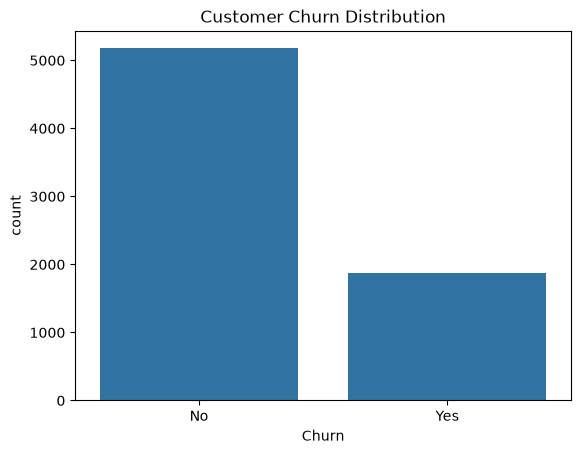

In [13]:
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.show()

In [14]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [15]:
df = df.drop("customerID", axis=1)

In [16]:
df.shape

(7043, 20)

In [17]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [18]:
print(df["TotalCharges"].isnull().sum())

11


In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [20]:
y = y.map({
    "No": 0,
    "Yes": 1
})

In [21]:
print(y.value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [22]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [23]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [24]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (4930, 19)
Validation: (1056, 19)
Testing: (1057, 19)


In [26]:
numerical_columns = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X_train.select_dtypes(
    include=["str"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical columns:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [28]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [29]:
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [30]:
preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_columns),
    ("cat", categorical_pipeline, categorical_columns)
])

In [31]:
X_train_processed = preprocessor.fit_transform(X_train)
X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Validation shape:", X_val_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (4930, 45)
Validation shape: (1056, 45)
Testing shape: (1057, 45)


In [32]:
preprocessor.transform(X_val)
preprocessor.transform(X_test)

array([[ 2.28233828, -0.62779138, -0.65805827, ...,  0.        ,
         1.        ,  0.        ],
       [-0.43814715,  0.42723857, -0.28438852, ...,  0.        ,
         0.        ,  1.        ],
       [-0.43814715,  1.60400274,  0.39185454, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.43814715, -0.70894753, -0.53405282, ...,  0.        ,
         0.        ,  1.        ],
       [-0.43814715,  1.19822199,  0.00495754, ...,  0.        ,
         0.        ,  1.        ],
       [ 2.28233828,  0.54897279,  1.30618806, ...,  0.        ,
         1.        ,  0.        ]], shape=(1057, 45))

In [36]:
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

In [37]:
start = time.perf_counter()

logistic_pipeline.fit(X_train, y_train)

train_time = time.perf_counter() - start

print("Training time:", train_time, "seconds")

Training time: 0.24645226299981005 seconds


In [38]:
start = time.perf_counter()

y_val_pred = logistic_pipeline.predict(X_val)

inference_time = time.perf_counter() - start

print("Inference time:", inference_time, "seconds")

Inference time: 0.027038125997933093 seconds


In [39]:
y_val_prob = logistic_pipeline.predict_proba(X_val)[:, 1]

In [40]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred)
recall = recall_score(y_val, y_val_pred)
f1 = f1_score(y_val, y_val_pred)
roc_auc = roc_auc_score(y_val, y_val_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
print("ROC-AUC  :", roc_auc)

Accuracy : 0.8058712121212122
Precision: 0.6459143968871596
Recall   : 0.5928571428571429
F1-score : 0.6182495344506518
ROC-AUC  : 0.8453124999999999


In [42]:
cm = confusion_matrix(y_val, y_val_pred)

print(cm)

[[685  91]
 [114 166]]


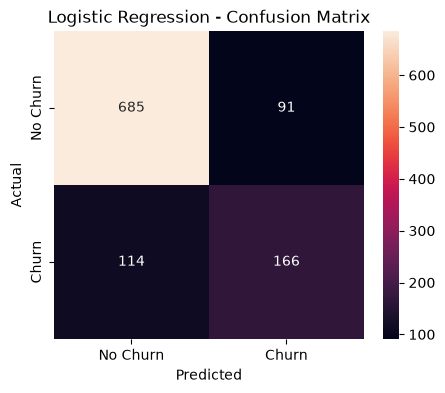

In [43]:
plt.figure(figsize=(5, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [44]:
from sklearn.neighbors import KNeighborsClassifier

In [46]:
knn3_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=3))
])

In [47]:
start = time.perf_counter()

knn3_pipeline.fit(X_train, y_train)

knn3_train_time = time.perf_counter() - start

print("Training time:", knn3_train_time, "seconds")

Training time: 0.08072838499720092 seconds


In [48]:
start = time.perf_counter()

knn3_pred = knn3_pipeline.predict(X_val)

knn3_inference_time = time.perf_counter() - start

print("Inference time:", knn3_inference_time, "seconds")

Inference time: 0.11441585899956408 seconds


In [49]:
knn3_prob = knn3_pipeline.predict_proba(X_val)[:, 1]

In [50]:
print("Accuracy :", accuracy_score(y_val, knn3_pred))
print("Precision:", precision_score(y_val, knn3_pred))
print("Recall   :", recall_score(y_val, knn3_pred))
print("F1-score :", f1_score(y_val, knn3_pred))
print("ROC-AUC  :", roc_auc_score(y_val, knn3_prob))

Accuracy : 0.7490530303030303
Precision: 0.5244299674267101
Recall   : 0.575
F1-score : 0.5485519591141397
ROC-AUC  : 0.7525358983799706


In [52]:
knn7_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=7))
])

In [53]:
start = time.perf_counter()

knn7_pipeline.fit(X_train, y_train)

knn7_train_time = time.perf_counter() - start

In [54]:
start = time.perf_counter()

knn7_pred = knn7_pipeline.predict(X_val)

knn7_inference_time = time.perf_counter() - start

In [55]:
knn7_prob = knn7_pipeline.predict_proba(X_val)[:, 1]

In [56]:
print("Accuracy :", accuracy_score(y_val, knn7_pred))
print("Precision:", precision_score(y_val, knn7_pred))
print("Recall   :", recall_score(y_val, knn7_pred))
print("F1-score :", f1_score(y_val, knn7_pred))
print("ROC-AUC  :", roc_auc_score(y_val, knn7_prob))

Accuracy : 0.7727272727272727
Precision: 0.5684931506849316
Recall   : 0.5928571428571429
F1-score : 0.5804195804195804
ROC-AUC  : 0.8060866163475701


In [57]:
from sklearn.tree import DecisionTreeClassifier

In [58]:
dt_shallow_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        random_state=42
    ))
])

In [59]:
start = time.perf_counter()

dt_shallow_pipeline.fit(X_train, y_train)

dt_shallow_train_time = time.perf_counter() - start

print("Training time:", dt_shallow_train_time, "seconds")

Training time: 0.19207938999898033 seconds


In [60]:
start = time.perf_counter()

dt_shallow_pred = dt_shallow_pipeline.predict(X_val)

dt_shallow_inference_time = time.perf_counter() - start

print("Inference time:", dt_shallow_inference_time, "seconds")

Inference time: 0.13247193999995943 seconds


In [61]:
dt_shallow_prob = dt_shallow_pipeline.predict_proba(X_val)[:, 1]

In [62]:
print("Accuracy :", accuracy_score(y_val, dt_shallow_pred))
print("Precision:", precision_score(y_val, dt_shallow_pred))
print("Recall   :", recall_score(y_val, dt_shallow_pred))
print("F1-score :", f1_score(y_val, dt_shallow_pred))
print("ROC-AUC  :", roc_auc_score(y_val, dt_shallow_prob))

Accuracy : 0.7935606060606061
Precision: 0.7012987012987013
Recall   : 0.38571428571428573
F1-score : 0.4976958525345622
ROC-AUC  : 0.8246203055964654


In [63]:
dt_deep_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ))
])

In [64]:
start = time.perf_counter()

dt_deep_pipeline.fit(X_train, y_train)

dt_deep_train_time = time.perf_counter() - start

print("Training time:", dt_deep_train_time, "seconds")

Training time: 0.21541181900101947 seconds


In [65]:
start = time.perf_counter()

dt_deep_pred = dt_deep_pipeline.predict(X_val)

dt_deep_inference_time = time.perf_counter() - start

print("Inference time:", dt_deep_inference_time, "seconds")

Inference time: 0.12636836399906315 seconds


In [66]:
dt_deep_prob = dt_deep_pipeline.predict_proba(X_val)[:, 1]

In [67]:
print("Accuracy :", accuracy_score(y_val, dt_deep_pred))
print("Precision:", precision_score(y_val, dt_deep_pred))
print("Recall   :", recall_score(y_val, dt_deep_pred))
print("F1-score :", f1_score(y_val, dt_deep_pred))
print("ROC-AUC  :", roc_auc_score(y_val, dt_deep_prob))

Accuracy : 0.7244318181818182
Precision: 0.48
Recall   : 0.4714285714285714
F1-score : 0.4756756756756757
ROC-AUC  : 0.6637564432989691


In [68]:
dt_deep_train_pred = dt_deep_pipeline.predict(X_train)

print("Training Accuracy:", accuracy_score(y_train, dt_deep_train_pred))
print("Validation Accuracy:", accuracy_score(y_val, dt_deep_pred))

Training Accuracy: 0.9669371196754564
Validation Accuracy: 0.7244318181818182


In [69]:
dt_shallow_train_pred = dt_shallow_pipeline.predict(X_train)

print("Shallow Tree Training Accuracy:",
      accuracy_score(y_train, dt_shallow_train_pred))

print("Shallow Tree Validation Accuracy:",
      accuracy_score(y_val, dt_shallow_pred))

Shallow Tree Training Accuracy: 0.7914807302231237
Shallow Tree Validation Accuracy: 0.7935606060606061


In [70]:
dt_deep_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        max_depth=15,
        random_state=42
    ))
])

In [71]:
start = time.perf_counter()

dt_deep_pipeline.fit(X_train, y_train)

dt_deep_train_time = time.perf_counter() - start

print("Training time:", dt_deep_train_time, "seconds")

Training time: 0.10417332199722296 seconds


In [72]:
start = time.perf_counter()

dt_deep_pred = dt_deep_pipeline.predict(X_val)

dt_deep_inference_time = time.perf_counter() - start

print("Inference time:", dt_deep_inference_time, "seconds")

Inference time: 0.026244136999594048 seconds


In [73]:
dt_deep_prob = dt_deep_pipeline.predict_proba(X_val)[:, 1]

In [74]:
print("Accuracy :", accuracy_score(y_val, dt_deep_pred))
print("Precision:", precision_score(y_val, dt_deep_pred))
print("Recall   :", recall_score(y_val, dt_deep_pred))
print("F1-score :", f1_score(y_val, dt_deep_pred))
print("ROC-AUC  :", roc_auc_score(y_val, dt_deep_prob))

Accuracy : 0.7244318181818182
Precision: 0.48
Recall   : 0.4714285714285714
F1-score : 0.4756756756756757
ROC-AUC  : 0.6637564432989691


In [75]:
dt_deep_train_pred = dt_deep_pipeline.predict(X_train)

print("Deep Tree Training Accuracy:",
      accuracy_score(y_train, dt_deep_train_pred))

print("Deep Tree Validation Accuracy:",
      accuracy_score(y_val, dt_deep_pred))

Deep Tree Training Accuracy: 0.9669371196754564
Deep Tree Validation Accuracy: 0.7244318181818182


In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])